<img src="images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# Random Forests

Random Forests are among the most widely used machine learning algorithms for both classification and regression tasks. They belong to a family of methods known as **ensemble learning** techniques, where multiple models are combined to produce a stronger overall predictor. Instead of relying on a single Decision Tree, a Random Forest trains many Decision Trees and aggregates their predictions. For classification tasks, the final prediction is typically obtained through majority voting, while regression tasks use averaging. By combining many diverse trees, Random Forests are often able to achieve significantly better generalization performance than an individual Decision Tree.

A key motivation behind Random Forests is that individual Decision Trees can easily overfit the training data. A deep Decision Tree may memorize noise and produce unstable predictions, where small changes in the training data can lead to very different tree structures. Random Forests reduce this instability by introducing randomness during training and then averaging across many trees. This process lowers variance while still retaining the expressive power of Decision Trees. As a result, Random Forests are often highly accurate while requiring relatively little feature preprocessing compared to many other machine learning methods.

Two important mechanisms make Random Forests effective: **bootstrap sampling** (also called bagging) and **feature sampling**. During bagging, each tree is trained on a randomly sampled subset of the training data drawn with replacement. This ensures that different trees see slightly different datasets, increasing diversity among the trees. Additionally, at each split in a tree, only a random subset of features is considered instead of all available features. Feature sampling further decorrelates the trees by preventing a few dominant features from controlling every split. Together, these sources of randomness help create a collection of diverse models whose combined predictions are more robust and less prone to overfitting.

In this notebook, we will explore the fundamental ideas behind Random Forests and examine how they extend Decision Trees into a powerful ensemble learning method. In addition to using existing machine learning libraries, the notebook also includes a basic implementation of both a Random Forest classifier and a Random Forest regressor from scratch. Implementing these algorithms manually provides valuable insight into how bagging, feature sampling, tree construction, and prediction aggregation work internally. Understanding these implementation details helps build a deeper intuition for ensemble learning beyond simply calling library functions.

Learning about Random Forests is important because they are widely applied across many real-world domains, including finance, healthcare, cybersecurity, recommendation systems, and scientific data analysis. They often provide strong baseline performance, handle nonlinear relationships naturally, work well with mixed and noisy data, and require relatively little hyperparameter tuning. Even with the rise of deep learning, Random Forests remain a highly practical and dependable tool for structured/tabular datasets, making them an essential algorithm in the machine learning toolkit.

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.tree import plot_tree

from src.models.trees.rf import SeleneRandomForestClassifier, SeleneRandomForestRegressor
from src.utils.data.files import *

#### Download Required Data

Some code examples in this notebook use data that first need to be downloaded by running the code cell below. If this code cell throws any error, please check the configuration file `config.yaml` if the URL for downloading datasets is up to date and matches the one on Github. If not, simply download or pull the latest version from Github.

In [2]:
creadit_loans, _ = download_dataset("tabular/classification/example-loan-default-data.csv")
breast_cancer, _ = download_dataset("tabular/classification/breast-cancer-wisconsin-classification.csv")

File 'data/datasets/tabular/classification/example-loan-default-data.csv' already exists (use 'overwrite=True' to overwrite it).


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 121k/121k [00:00<00:00, 12.8MiB/s]


#### Preparation of Toy Dataset

For the recap about Decision Trees and the introduction to Random Forest, we use a very small synthetic dataset. This dataset contains the historical information about loan applications for $10$ bank customers. Let's first load the dataset file into a Pandas DataFrame and have a look at the different values.

In [3]:
df_loan = pd.read_csv(creadit_loans)

df_loan.head(10)

,ANNUAL_INCOME,CREDIT_SCORE,DEBT_RATIO,YEARS_EMPLOYED,DEFAULTED,LOAN_AMOUNT
0,45,620,0.42,2,1,28
1,82,710,0.21,8,1,32
2,60,680,0.35,5,0,30
3,38,590,0.51,1,1,12
4,95,760,0.18,12,0,15
5,72,700,0.29,7,0,38
6,50,640,0.47,3,1,20
7,11,790,0.15,15,0,70
8,67,675,0.33,6,0,34
9,40,605,0.49,2,1,15


Note that, in this dataset, the values for the annual income and the loan amount are expressed in thousands; for example, an annual income value of $45$ means that the annual income of this customer is $45,000$ (we do not care about the currency here).

Throughout the notebook, we consider the annual income, the credit score, the debt ratio, and the years of employment as the input features for each customer. The information whether customers defaulted on their credit and the loan amount are considered potential targets, depending if we consider a classification or regression task. In case of a classification task, we want to use the input features to predict if a customer will default on their credit. For this, we can create the NumPy arrays `X` and `y` representing the feature matrix and target vector, respectively, as follows:

In [4]:
X_classification = df_loan.drop(["DEFAULTED", "LOAN_AMOUNT"], axis=1).to_numpy()
y_classification = df_loan["DEFAULTED"].to_numpy()

For the regression task, we assume we want to train a model predict the loan amount based on the input features; again, we can directly create the feature matrix `X` and target vector:

In [5]:
X_regression = df_loan.drop(["DEFAULTED", "LOAN_AMOUNT"], axis=1).to_numpy()
y_regression = df_loan["LOAN_AMOUNT"].to_numpy()

Later, when visualizing Decision Trees, it also helps to have all feature names as a list:

In [6]:
feature_names = df_loan.columns[:4].to_numpy()

print(feature_names)

['ANNUAL_INCOME' 'CREDIT_SCORE' 'DEBT_RATIO' 'YEARS_EMPLOYED']


---

## Quick Recap: Decision Trees

Random Forests are an ensemble model based on Decision Trees. It is therefore worthwhile to provide a quick overview to Decision Trees and their limitations, which will motivate the ideas behind Random Forests.

### Basic Idea

Decision Trees are a supervised machine learning method used for both **classification and regression tasks**. The basic idea is to recursively split the dataset into smaller and more homogeneous groups based on the values of the input features. Starting from the root node, the algorithm searches for a feature and threshold that best separates the data according to some criterion, such as Gini impurity, entropy, or mean squared error. Each internal node in the tree represents a decision rule, each branch represents the outcome of that rule, and each leaf node contains the final prediction. During inference, a sample is passed through the tree by following the decision rules until it reaches a leaf node.

For classification tasks, a Decision Tree attempts to create groups where most samples belong to the same class. For regression tasks, the tree tries to group samples with similar target values together. Because the model repeatedly partitions the feature space into smaller regions, Decision Trees can naturally capture nonlinear relationships and interactions between features without requiring extensive preprocessing or feature engineering. They are also easy to visualize and interpret, making them attractive for applications where model explainability is important.

In principle, Decision Trees naturally **support both numerical and categorical features**. For categorical data, a tree could directly split on feature values such as *"red vs blue vs green"* or *"student vs employed vs retired" without requiring any numerical encoding. This flexibility is one reason Decision Trees are conceptually appealing, since the recursive partitioning process can be applied to many different types of data. Furthermore, trees are not fundamentally limited to binary splits; a categorical feature with multiple categories could, in theory, produce multi-way branches where each category corresponds to its own child node.

However, many practical implementations, including those in [scikit-learn](https://scikit-learn.org), primarily assume numerical input features and perform only binary splits based on thresholds. One reason is computational efficiency: binary threshold splits are much easier and faster to optimize, especially for large datasets and high-dimensional feature spaces. Restricting the tree to binary splits also simplifies the implementation and leads to more uniform tree structures. As a result, categorical variables are often converted into numerical representations, such as one-hot encoding, before training. Although this may appear restrictive, binary-split trees remain highly expressive and can still model complex decision boundaries effectively.

To give an example, we can train a Decision Tree classifier using the [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) class provided by [scikit-learn](https://scikit-learn.org) on our toy dataset. The code cell below shows the minimal code example to accomplish this; note that the class provides a series of arguments (e.g., the maximum depth of the tree) that impact the training. For the example below, we stick to the default parameters. Note that we also set a random seed to ensure consistent results, as this implementation of Decision Trees has random components (incl. the random breaking of ties in case different alternatives to split a node are equally good).

In [7]:
np.random.seed(1)

sklearn_classifier = DecisionTreeClassifier().fit(X_classification, y_classification)

[scikit-learn](https://scikit-learn.org) also provides the auxiliary method `plot_tree()` to visualize the trained Decision Tree, which in our case is only a small tree since we only used a very small training dataset.

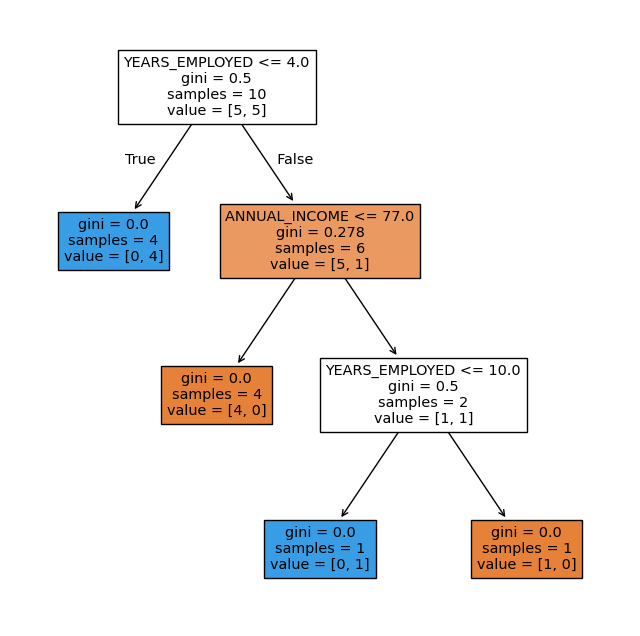

In [8]:
plt.figure(figsize=(8, 8))
plot_tree(sklearn_classifier, filled=True, feature_names=feature_names)
plt.show()

This visualization clearly shows the decision rule for each inner node (i.e., non-leaf node). For example, the root node is telling us that the first split depends on the years of employment and that the threshold value for this split is $4$ years. Thus all customers with less than or equal to $4$ years employment fall into the left branch, while all other customers fall into the right branch. Then the splitting of nodes continues until a node has only samples (here: customers) with the same class label.

In this example, we build the *full* Decision Tree, meaning growing the tree until no further meaningful splits can be made. In practice, this often means continuing the recursive splitting process until every leaf node contains only samples from a single class, only a very small number of samples, or no additional split can improve the impurity measure. Such a tree can become very deep and highly specialized to the training data. Because Decision Trees greedily optimize splits at each node, a fully grown tree may fit even small fluctuations and noise present in the dataset.

While a full tree can achieve extremely low training error, it often performs poorly on unseen data due to **overfitting**. The model effectively memorizes the training set instead of learning more general patterns. To address this problem, practical Decision Tree implementations usually restrict the size or complexity of the tree. Common approaches include limiting the maximum tree depth, requiring a minimum number of samples per split or other criteria, restricting the maximum number of leaf nodes, or applying pruning techniques that remove unnecessary branches after training. These constraints help produce simpler and more robust trees that generalize better to new data. Again, we cover these issues and countermeasures in much more depths in the dedicated Decision Tree notebooks.

### Pros and Cons

Decision Trees have several important advantages that make them widely used in machine learning, especially for structured/tabular datasets:

* **Interpretability and explainability:** A Decision Tree represents its predictions as a sequence of human-readable decision rules, making it easy to visualize and understand how predictions are produced. Unlike many black-box models, trees allow practitioners to inspect which features are important and how specific decisions are made. This makes them attractive in domains such as healthcare, finance, and business analytics where explainability is important.

* **Ability to model nonlinear relationships:** Decision Trees can naturally model nonlinear relationships and feature interactions without requiring complex feature engineering. The recursive splitting process partitions the feature space into regions that can represent highly nonlinear decision boundaries. Trees also require relatively little preprocessing compared to many other algorithms: they do not require feature scaling or normalization and can work with features measured on very different scales.

* **Flexibility:** Decision Trees are also highly flexible because they support both classification and regression tasks. In principle, they can handle numerical and categorical data and can be adapted to many different impurity measures and optimization criteria. Furthermore, they are computationally efficient during inference, since predictions only require traversing a path from the root node to a leaf node.

On the other hand, Decision Trees also have various limitations that may affect the application to practical learning tasks:

* **Overfitting and high variance:** Decision Trees are highly prone to overfitting, especially when trained as deep or full trees. Because the model recursively partitions the training data into increasingly smaller regions, it may begin to memorize noise and small fluctuations rather than learning generalizable patterns. This also makes Decision Trees unstable models: small changes in the training data can lead to very different split decisions and tree structures. As a result, individual trees often exhibit high variance and may generalize poorly to unseen data.

* **Greedy and locally optimal training:** Most Decision Tree algorithms are trained using a greedy top-down procedure that optimizes one split at a time. While this approach is computationally efficient, it does not guarantee a globally optimal tree structure. A split that appears best at an early stage may later prevent the discovery of a better overall partitioning of the data. Since finding the truly optimal Decision Tree is computationally infeasible in general, practical algorithms rely on heuristics that may produce suboptimal solutions.

* **Limitations of standard binary splits:**  Many Decision Tree implementations, such as those in [scikit-learn](https://scikit-learn.org), use binary threshold-based splits. While computationally efficient, these axis-aligned splits can struggle to represent certain geometric relationships efficiently. Complex decision boundaries may require very deep trees with many splits, increasing model complexity and the risk of overfitting. Additionally, features with many possible split points may dominate the splitting process and bias feature selection.

* **Limited regression and extrapolation capabilities:** Decision Tree regressors produce piecewise constant predictions, meaning that all samples within a leaf node receive the same predicted value. Consequently, predictions are not smooth and may change abruptly between neighboring regions. Furthermore, Decision Trees generally cannot extrapolate beyond the range of target values observed during training. This limitation can make them less suitable for tasks where smooth trends or extrapolation outside the training distribution are important.

* **Single trees often underperform ensemble methods:** Although Decision Trees are intuitive and interpretable, individual trees are often less accurate and less robust than ensemble methods. In practice, techniques such as Random Forest and boosted trees are frequently preferred because they combine many trees to reduce variance, improve stability, and achieve significantly better predictive performance. As a result, standalone Decision Trees are often used more as educational tools or interpretable baseline models than as state-of-the-art predictive systems.

Random Forests were primarily developed to address two major limitations of individual Decision Trees: overfitting and high variance. Random Forests reduce these problems by training many different Decision Trees and combining their predictions through averaging (for regression) or majority voting (for classification). By aggregating many trees, the ensemble becomes more stable, less sensitive to individual training examples, and significantly more robust against overfitting. To encourage diversity among the trees, Random Forests introduce randomness through bootstrap sampling and feature sampling. In the next section, we will discuss how all these ideas come together.

---

## Random Forest &mdash; Core Components

A Random Forest is an example of an **ensemble model**, meaning that it combines the predictions of many individual models to produce a stronger and more robust overall predictor. Instead of relying on a single Decision Tree, a Random Forest trains many different trees and aggregates their predictions through majority voting for classification or averaging for regression. The motivation behind ensemble methods is that while individual models may make errors or overfit certain parts of the data, combining many diverse models often reduces variance, improves stability, and leads to better generalization performance. By leveraging the collective behavior of multiple Decision Trees, Random Forests are typically much more accurate and reliable than a single standalone tree.

The effectiveness of a Random Forest depends on the individual Decision Trees being meaningfully different from one another. If all trees were trained identically and produced nearly the same predictions, combining them would provide little benefit over using a single tree. The power of ensemble learning comes from aggregating diverse models whose errors are not perfectly correlated. Different trees may overfit different parts of the training data or make different mistakes, and averaging or voting across these diverse predictions helps cancel out individual errors and reduce variance. This is why Random Forests deliberately introduce randomness through **bootstrap sampling** and random **feature selection**, encouraging the trees to learn different patterns and decision boundaries.

### Bootstrap Sampling (Bagging)

Bootstrap sampling is a technique where we create multiple different training datasets by randomly sampling from the original dataset **with replacement**. This means that each sample is drawn independently, so the same data point can appear multiple times in a bootstrap sample, while some original data points may not appear at all. In the context of models like Random Forest, each Decision Tree is trained on its own bootstrap sample, which introduces variation between trees even though they are trained on the same underlying dataset. This diversity is important because it helps reduce correlation between models and improves the overall stability and generalization performance of the ensemble.

To illustrate the idea, we can create a bootstrap sample directly for the Pandas DataFrame `df_loan` containing our toy dataset. For comparison, let's first print the original dataset again.

In [9]:
df_loan.head(10)

,ANNUAL_INCOME,CREDIT_SCORE,DEBT_RATIO,YEARS_EMPLOYED,DEFAULTED,LOAN_AMOUNT
0,45,620,0.42,2,1,28
1,82,710,0.21,8,1,32
2,60,680,0.35,5,0,30
3,38,590,0.51,1,1,12
4,95,760,0.18,12,0,15
5,72,700,0.29,7,0,38
6,50,640,0.47,3,1,20
7,11,790,0.15,15,0,70
8,67,675,0.33,6,0,34
9,40,605,0.49,2,1,15


Pandas provides the built-in method `sample()` to sample rows from a DataFrame. Since we want to perform bootstrap sampling, the size of the sample will be the same as the size of the original dataset, and we need to sample with replacement. The method `sample()` allows us to specify both these requirements using the input arguments `n` and `replace`; we also set the random state to ensure the same result for consistency.

In [10]:
df_loan_boostrap = df_loan.sample(n=len(df_loan), replace=True, random_state=42)

df_loan_boostrap.head(10)

,ANNUAL_INCOME,CREDIT_SCORE,DEBT_RATIO,YEARS_EMPLOYED,DEFAULTED,LOAN_AMOUNT
6,50,640,0.47,3,1,20
3,38,590,0.51,1,1,12
7,11,790,0.15,15,0,70
4,95,760,0.18,12,0,15
6,50,640,0.47,3,1,20
9,40,605,0.49,2,1,15
2,60,680,0.35,5,0,30
6,50,640,0.47,3,1,20
7,11,790,0.15,15,0,70
4,95,760,0.18,12,0,15


Notice how the bootstrap sample no may contain the same original row multiple times but is missing some other rows.

In practice, we typically do not work on Pandas DataFrames but on NumPy arrays, but implementing bootstrap sampling using NumPy is equally straightforward; see the method `create_boostrap_sample()` in the code cell below. First, it determines the number of training examples using `n_samples = X.shape[0]`, which corresponds to the number of rows in the feature matrix `X`. It then creates a random set of indices using [`np.random.choice()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html), where it samples `n_samples` indices from the range `[0, n_samples-1]` *with replacement*. Sampling with replacement means that some indices may appear multiple times while others may not appear at all. Next, these randomly selected indices are used to construct the bootstrap dataset. The feature matrix `X_bootstrap` and target vector `y_bootstrap` are created by indexing into the original data using `random_sample_indices`. This produces a new dataset of the same size as the original, but with repeated and omitted samples, introducing randomness and diversity.

In [11]:
def create_bootstrap_sample(X, y):
    X_bootstrap, y_bootstrap = None, None
    # Get the number of samples from the shape of the original feature matrix
    n_samples = X.shape[0]
    # Sample randomly n_samples indicies 0..(n_samples-1) with replacement
    random_sample_indices = np.random.choice(n_samples, n_samples, replace=True)
    # Construct the feature matrix and the target vector using the sampled indices
    X_bootstrap = X[random_sample_indices]
    y_bootstrap = y[random_sample_indices]
    # Return the bootstrap sample
    return X_bootstrap, y_bootstrap

For a quick test, we can apply this method to our toy dataset for the classification task:

In [12]:
X_bootstrap, y_bootstrap = create_bootstrap_sample(X_classification, y_classification)

print('Shape of X_bootstrap: {}'.format(X_bootstrap.shape))
print('Shape of y_bootstrap: {}'.format(y_bootstrap.shape))

Shape of X_bootstrap: (10, 4)
Shape of y_bootstrap: (10,)


Of course, the shapes of the feature matrix and the target vector for the bootstrap sample are identical to the shapes of the original feature matrix and target vector. However, the actual set of samples (here: customers) is likely to be different due to the random sampling with replacement.

### Feature Sampling

Bootstrap sampling alone is often not sufficient to create truly diverse Decision Trees, especially when the dataset contains one or more **strong predictors**. A strong predictor is a feature that has a very high predictive power for the target variable &mdash; for example, it consistently provides splits that significantly reduce impurity or error across many subsets of the data. In such cases, even though each tree in a Random Forest is trained on a different bootstrap sample, the same strong feature will tend to dominate the splitting decisions at the top of most trees. As a result, many trees end up having very similar structures and making correlated errors, which limits the benefit of averaging.

This is where **feature sampling** comes in. Feature sampling is a technique where, at each split in a Decision Tree, only a random subset of the available features is considered instead of evaluating all features. This introduces additional randomness into the tree-building process, ensuring that different trees in an ensemble are exposed to different feature subsets and therefore learn different decision structures. In models such as Random Forest, this is combined with bootstrap sampling to further reduce correlation between trees. The key motivation is to prevent a few strong predictors from dominating every tree, which would otherwise lead to highly similar trees and limit the benefits of ensembling. By forcing each split to "choose from fewer options", feature sampling increases diversity among trees and improves overall generalization performance.

Again, we can illustrate the idea behind feature sampling using our DataFrame `df_loan`; let's first print the original data for comparison.

In [13]:
df_loan.head(10)

,ANNUAL_INCOME,CREDIT_SCORE,DEBT_RATIO,YEARS_EMPLOYED,DEFAULTED,LOAN_AMOUNT
0,45,620,0.42,2,1,28
1,82,710,0.21,8,1,32
2,60,680,0.35,5,0,30
3,38,590,0.51,1,1,12
4,95,760,0.18,12,0,15
5,72,700,0.29,7,0,38
6,50,640,0.47,3,1,20
7,11,790,0.15,15,0,70
8,67,675,0.33,6,0,34
9,40,605,0.49,2,1,15


The code below now randomly selects two feature names from the list `feature_names` &mdash; after all, we do not want to sample any target columns as features &mdash; and creates a new DataFrame containing only those sampled features. First, `pd.Series(feature_names)` converts the list of feature names into a Pandas Series so that the `.sample()` method can be used. The method `.sample(n=2, replace=False, random_state=42)` randomly chooses two distinct feature names without replacement, while `random_state=42` ensures reproducible results. The selected feature names are then converted into a regular Python list using `.tolist()`. Next, `df_loan[sampled_features]` creates a new DataFrame `df_loan_sampled` containing only the sampled columns from the original DataFrame `df_loan`.

In [14]:
# Randomly sample 2 features from the subset
sampled_features = (
    pd.Series(feature_names)
    .sample(n=2, replace=False, random_state=42)
    .tolist()
)

# Create DataFrame with sampled features
df_loan_sampled = df_loan[sampled_features]

df_loan_sampled.head(10)

,CREDIT_SCORE,YEARS_EMPLOYED
0,620,2
1,710,8
2,680,5
3,590,1
4,760,12
5,700,7
6,640,3
7,790,15
8,675,6
9,605,2


Feel free to change the value of `random_state` or remove this argument all together to see different results.

Assuming NumPy arrays, feature sampling is also easy to implement; the method `sample_feature_indices()` shows an example. The method first determines the total number of available features in the dataset using `X.shape[1]`. This value is stored in `n_features` and initially represents how many features exist in the full feature space. Next, the function checks whether a `max_features` constraint was provided. If `max_features` is not `None` and is greater than 1, it limits the number of features to sample by taking the minimum of the total number of features and `max_features`. This ensures that the algorithm does not try to select more features than actually exist. Finally, finally randomly selects a subset of feature indices using `np.random.choice`. The function samples `n_features` indices from the full set of feature indices `[0, 1, ..., X.shape[1]-1]` **without replacement**, meaning each selected feature appears only once in the subset.

In [15]:
def sample_feature_indices(X, max_features: int=None):
    # Get the number of available features
    n_features = X.shape[1]
    # Compute sample size as the minimum of available features and max_features value
    if max_features is not None and max_features > 1:
        n_features = min(n_features, max_features)
    # Return a random sample of available indices of size n_features (without replacement)
    return np.random.choice(np.arange(X.shape[1]), size=n_features, replace=False)

Let's apply the method a few times on the feature matrix of our toy dataset using `max_features=2`; recall that the original dataset has $4$ features.

In [16]:
for _ in range(5):
    sampled_indices = sample_feature_indices(X_classification, max_features=2)
    print(f"Sampled feature indices: {sampled_indices}")

Sampled feature indices: [3 1]
Sampled feature indices: [3 1]
Sampled feature indices: [1 3]
Sampled feature indices: [3 0]
Sampled feature indices: [3 2]


**Important:** Random Forests apply feature sampling at the **per-split (per-decision node) level**, meaning that at every node in every tree, a new random subset of features is selected for evaluating possible splits. This is different from selecting a single subset of features per entire tree. The reason for this design is to maximize diversity among trees while also diversifying decisions within each tree. If feature sampling were done only once per tree, then each tree would be restricted to a fixed subset of features, which could still lead to relatively similar tree structures &mdash; especially when strong predictors exist. By resampling features at every split, each tree is forced to explore different decision paths, further reducing correlation between trees in the ensemble and improving the overall robustness and generalization performance of models like Random Forest.

Also note that the method `sample_feature_indices()` was mainly to show that feature sampling is not difficult to implement. However, moving forward, we actually won't be using this method for two simple reasons:

* **Built-in feature sampling:** In the following, when implementing Random Forests using existing Decision Tree implementations, both [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) and [`DecisionTreeRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) support feature subsampling internally through the `max_features` parameter, which controls how many features are considered at each split. During training, the algorithm automatically handles the random selection of feature subsets (when `max_features` is set below the total number of features), so each split only evaluates a limited set of candidate features.

* **More flexible sampling strategies:** The method `sample_feature_indices()` assumes that `max_features`, if provided, is an integer, meaning it directly specifies the maximum number of features to sample at each split. However, in practical machine learning implementations, `max_features` is often more flexible and can take other forms. For example, it may be specified as a fraction (e.g., $0.5$ to use half of the features), or as a function-based rule such as `"sqrt"` or `"log2"`, which automatically determines the number of features based on the total feature count. These alternatives make the model easier to configure across datasets of different sizes and help standardize behavior without requiring manual tuning of an exact integer value. However, the fundamental idea of restricting the feature set remains exactly the same.

### Training the Model

For training random forest, we assume we already have existing implementations of Decision Trees, either for classification or regression tasks. To the end, we will be using the [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) class and the [`DecisionTreeRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) class provided by [scikit-learn](https://scikit-learn.org). With these classes, implementing the "rest" of a Random Forest becomes quite straightforward.

#### Classifier Training

Let's start with training a Random Forest for classification tasks. Recall that training a Random Forest boils down to training multiple independent Decision Trees over different bootstrap samples and applying feature sampling when training each individual tree. The method `train_random_forest_classifer()` implements this idea for a Random Forest classifier. Apart from the training data &mdash; represented by the feature matrix `X` and the target vector `y`, the method has the following arguments

* `n_estimators`: integer values specifying the number of independent Decision Trees we want to train
* `max_depth:` integer value specifying the maximum depth of each Decision Tree
* `min_samples_split`: integer value specifying the minimum number of samples required to split an internal node
* `max_features:` integer value specifying the maximum number of randomly selected features for each split

Apart from the arguments, the method performs a simple loop where each iteration trains a Decision Tree classifier based on its own bootstrap sample. The number of iterations and thus the number of individual trees is naturally determined by the values of `n_estimators`. All the other arguments, including `max_features` for feature sampling, are passed to the `DecisionTreeClassifier` class to train the Decision Tree. Each trained tree is added to a list which is the return as our Random Forest classification model.

In [17]:
def train_random_forest_classifer(X, y, n_estimators: int=100, max_depth: int=None, min_samples_split: int=2, max_features: int=None):
    trees = []
    # Train n_estimators independent Decision trees using bootstrap and feature sampling
    for _ in range(n_estimators):
        # Create bootstrap sample
        X_bootstrap, y_bootstrap = create_bootstrap_sample(X, y)
        # Train a Decision Tree using boostrap sample; feature sampling is performed by Decision Tree implementation
        tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, max_features=max_features)
        tree = tree.fit(X_bootstrap, y_bootstrap)
        # Add trained to list
        trees.append(tree)
    # Return list of trees representing the Random forest
    return trees

We can now apply the method to our toy dataset for the classification task to train a Random Forest classifier. In the example below, we assume the default values for each argument, but you are welcome to manually change their values.

In [18]:
np.random.seed(11)

random_forest_classifier = train_random_forest_classifer(X_classification, y_classification)

print(f"Number of classification trees in Random Forest: {len(random_forest_classifier)}")

Number of classification trees in Random Forest: 100


Of course, the number of trees in the Random Forest should match the value of `n_estimators`.

#### Regressor Training

Training a Random Forest regressor is completely analogous. The only difference we have to make is the implementation of a Decision Tree regressor instead of a Decision Tree classifier for training the individual trees; all other steps remain the same. This small change is captured by the method `train_random_forest_regressor()` in the code cell below.

In [19]:
def train_random_forest_regressor(X, y, n_estimators: int=100, max_depth: int=None, min_sample_split: int=2, max_features: int=None):
    trees = []
    # Train n_estimators independent Decision trees using bootstrap and feature sampling
    for _ in range(n_estimators):
        # Create bootstrap sample
        X_bootstrap, y_bootstrap = create_bootstrap_sample(X, y)
        # Train a Decision Tree using boostrap sample; feature sampling is performed by Decision Tree implementation
        tree = DecisionTreeRegressor(max_depth=max_depth, min_samples_split=min_sample_split, max_features=max_features)
        tree = tree.fit(X_bootstrap, y_bootstrap)
        # Add trained to list
        trees.append(tree)
    # Return list of trees representing the Random forest
    return trees

Let's now also use this method to train a Random Forest regressor by applying the method on our toy dataset for the regression task.

In [20]:
np.random.seed(11)

random_forest_regressor = train_random_forest_regressor(X_regression, y_regression)

print(f"Number of regression trees in Random Forest: {len(random_forest_regressor)}")

Number of regression trees in Random Forest: 100


As you can see &mdash; assuming appropriate implementations of Decision Trees &mdash; implementing Random Forests is surprisingly easy (particularly if the Decision Tree implementation already supports feature sampling; although we saw that implementing feature sampling yourself is also not that difficult). The implementation of the two previous methods also make it very clear that a Random Forest is really just a list of independent Decision Trees. The application of bootstrap and feature sample ensures that all independent trees are unlikely to be (very) correlated.

To explore the last fact a little bit more, let's actually look at the first $3$ Decision Trees of our trained Random Forest Classifier

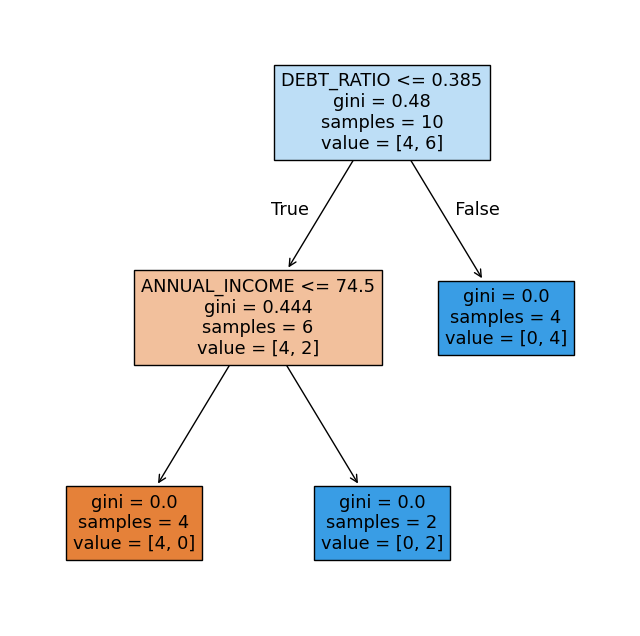

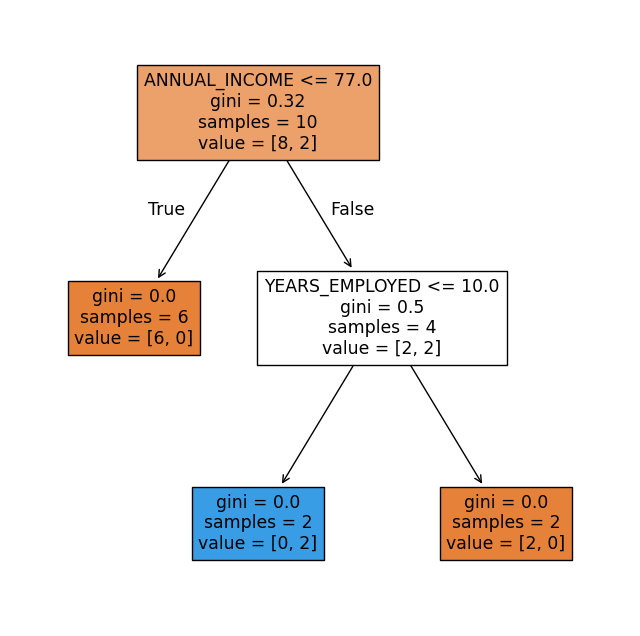

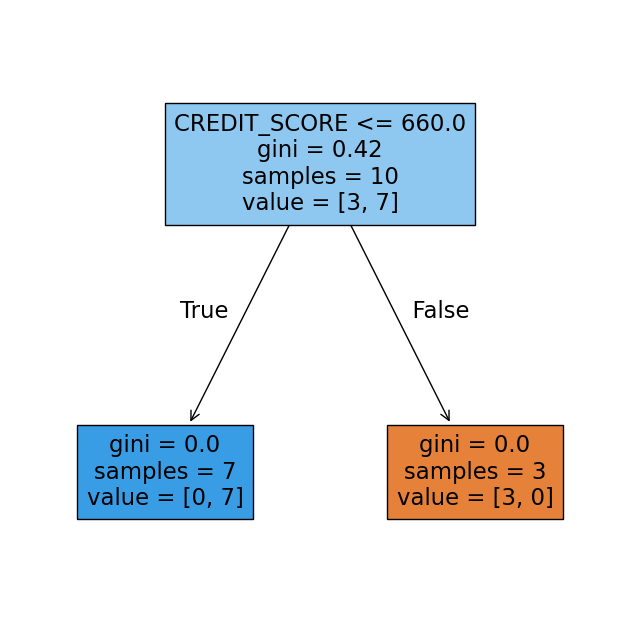

In [21]:
for idx in range(3):
    plt.figure(figsize=(8, 8))
    plot_tree(random_forest_classifier[idx], filled=True, feature_names=feature_names)
    plt.show()

Assuming the default values for the arguments as well as a random seed of $11$, you should see three trees that look noticeably different in terms of, among others, the choice of the root split and their sizes. Of course, if you print more than three trees and retrain the Random Forest with different random seeds, the displayed trees may be more or less similar or even identical. After all, our toy dataset has only $10$ samples and $4$ features, meaning that bootstrap sampling and feature sampling can only have a limited amount of diversity. Two more things to take note of here:

* **Choice of argument values:** Like before, we train full Decision Trees to form the Random Forest. While bootstrap and feature sampling help reduce the risk of overfitting, it might still be worthwhile to also restrain the size of each tree using appropriate values for `max_depth` and/or `min_samples_split`. In practice, as usual, we would try to determine the best values during hyperparameter tuning

* **Different trees, different predictions:** Just to emphasize this point again, it is not just about that the individual trees in a Random Forest just "look" different, they are also more likely to yield different predictions for unseen data. Each tree is likely to make wrong predictions for some kind of samples, and the expectation is that averaging all predictions (e.g., through majority voting) is likely to smooth out these individual errors.

How we use a trained Random Forest to make predictions, we will cover next.

### Making Predictions

Now that we have a trained Random Forest classifier or regressor, we want to use these models to actually make predictions for unseen data. The general idea is to let each individual tree in the forest make its own prediction and then average all predictions for the final prediction as the output. How the averaging is done mainly depends if we consider a classification or regression task.

#### Predicting Classes

In the case of a Random Forest classifier, each tree will predict a class label &mdash; and remember, different trees are likely to predict different labels. Averaging all class labels simply means finding the most common class label (i.e., **majority voting**). In Random Forests, all individual trees are equal in the sense that no tree is more important/useful/etc. than the others. Thus, there is no notion of assigning, say, weights to the outputs: the most frequent class label wins.

The method `predict_classes()` in the concept below implements this idea. First, the method passes the input dataset `X` to every decision tree in the forest using `tree.predict(X)`. Each tree independently predicts a class label for every sample in `X`. These predictions are collected into a 2D NumPy array `ys`, where each row corresponds to one tree and each column corresponds to one input sample. Thus, `ys[:, col]` contains all tree predictions for the `col`-th sample. Lastly, the method determines the final class prediction for each sample by selecting the class label that appears most frequently among all trees. This is done using [`np.bincount()`](https://numpy.org/doc/stable/reference/generated/numpy.bincount.html), which counts how often each integer class label occurs, followed by [`.argmax()`](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html), which returns the label with the highest count.

In [22]:
def predict_classes(X, random_forest_classifier):
    # Pass X to all trees to get all predictions
    ys = np.asarray([ tree.predict(X) for tree in random_forest_classifier ])
    # Compute the majority class label for each sample across all trees
    return np.array([ np.bincount(ys[:, col]).argmax() for col in range(ys.shape[1]) ])

Let's predict the class labels for our toy dataset. Keep in mind that we are using the same training samples and not unseen samples for this quick example; later we train and evaluate a Random Forest on a real-world dataset with a proper train-test split. Here it is just about showing the use of the method `predict_classes()`.

In [23]:
y_pred_classes = predict_classes(X_classification, random_forest_classifier)

print(f"Predicted classes for toy dataset: {y_pred_classes}")

Predicted classes for toy dataset: [1 1 0 1 0 0 1 0 0 1]


Since we are predicting the class labels for the training sample, it is not surprising that the prediction matches the ground truth for all samples; you can compare the output with the table showing the complete dataset at the beginning.

#### Predicting Values

Averaging the predictions of the individual trees of a Random Forest regressor is even more straightforward. Given that all predictions are numerical values &mdash; and again, all trees are treated as equally important &mdash; the final prediction for a sample is simply the mean of all predictions across all trees for this sample. This makes implementing this step even easier; see the method `predict_values()` in the code cell below. The array `ys` has the same interpretation as before, only that it now contains the numerical predictions instead of predicted class labels.

In [24]:
def predict_values(X, random_forest_regressor):
    # Pass X to all trees to get all predictions
    ys = np.asarray([ tree.predict(X) for tree in random_forest_regressor ])
    # Compute the mean for each sample across all trees
    return np.mean(ys, axis=0)

Again, let's predict the values for our training samples, just to see the use of this method.

In [25]:
y_pred_values = predict_values(X_regression, random_forest_regressor)

print(f"Predicted values for toy dataset: {y_pred_values}")

Predicted values for toy dataset: [24.04 32.59 30.78 14.26 28.46 36.38 21.56 54.68 33.84 15.81]


You will notice that the predicted values look quite a bit different than the ground truth values. Unlike a Random Forest classifier, which predicts the most common class label among all trees, a Random Forest regressor computes the final prediction by averaging the numerical predictions of all trees. As a result, even when the training samples themselves are passed back into the model, the predicted values will often not exactly match the original ground truth labels. Each individual decision tree may produce slightly different predictions because it was trained on a different bootstrap sample and may have seen different subsets of features during training. Averaging these predictions smooths the final output and reduces variance, but it also causes predictions to move toward the overall mean of the ensemble.

This effect is especially noticeable for samples whose target values are outliers. Since most trees are trained on only subsets of the data, many trees may not fully learn these extreme target values or may predict values closer to the general trend of the dataset. When all predictions are averaged together, the ensemble prediction is therefore "pulled" toward more typical values. Consequently, the difference between the predicted value and the true label is often largest for outliers in the ground truth labels. For example, the ground truth value for the 8th sample is $70$ (the largest value in our toy dataset). However, our trained Random Forest regressor &mdash; assuming the default values for all arguments and the random seed &mdash; predicts a value of $54.68$.

On the one hand, this behavior usually leads to better performance on unseen data and makes the model more stable and robust compared to a single decision tree. The averaging effect is particularly beneficial when the dataset contains noisy measurements or accidental extreme values. However, this same behavior can also be a disadvantage because the model tends to underestimate extreme target values and overestimate unusually small ones. In other words, predictions are biased toward the center of the observed target distribution. As a result, Random Forest regressors may struggle in applications where accurately predicting rare or extreme outcomes is important, such as financial risk analysis, anomaly detection, or forecasting unusually high demand.

---

## Worked Example

### Practical Implementation

So far, we implemented bootstrap sampling, training, and making prediction as individual methods (recall that feature sampling was provided by the off-the-shelf implementations of the Decision Tree classifier and regressors provided by [scikit-learn](https://scikit-learn.org)). Using this approach in practice would be a bit cumbersome. We therefore provided the two classes `SeleneRandomForestClassifier` and `SeleneRandomForestRegressor` in the file `src/models/trees/rf.py` if you want to check it out. However, these two classes simply combine the methods and functionalities we have covered so far, just to make them more convenient to use.

Regarding the names of the methods and arguments, we mimic the naming scheme of [scikit-learn](https://scikit-learn.org). For example, both classes have a `fit()` method to perform the training; but again, the functionality is the same as for the training methods we saw earlier. The code cell below shows defining and training a Random Forest classifier on our toy dataset using the `SeleneRandomForestClassifier` class and the `fit()` method.

In [26]:
classifier = SeleneRandomForestClassifier().fit(X_classification, y_classification)

Again, like [scikit-learn](https://scikit-learn.org), we provide both classes with a `predict()` method which implements the averaging &mdash; either majority voting for classification or computing the mean for regression &mdash; we like did before using the methods `predict_classes()` and `predict_values()`. This means we can now easily predict the classes for our toy dataset again.

In [27]:
y_pred_values = classifier.predict(X_classification)

print(f"Predicted classes for toy dataset: {y_pred_classes}")

Predicted classes for toy dataset: [1 1 0 1 0 0 1 0 0 1]


Creating and training and Random Forest regressor works exactly the same way. First we call the `fit()` method over the toy dataset to train the forest...

In [28]:
regressor = SeleneRandomForestRegressor().fit(X_regression, y_regression)

...and then we can call the `predict()` the method to predict the output values in terms of the mean of all individual predictions stemming from each tree.

In [29]:
y_pred_values = regressor.predict(X_regression)

print(y_pred_values)

[24.99 31.94 31.46 13.78 26.13 36.2  21.39 57.09 33.58 15.07]


**Note:** The purpose of the classes `SeleneRandomForestClassifier` and `SeleneRandomForestRegressor` is not to provide implementations of Random Forest you should use in practice. The classes [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) and [`RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) in the [scikit-learn](https://scikit-learn.org) library are more mature, more flexible, and much more optimized in terms of their efficiency. The main goal is to show that a class such as [`RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) does not need to be treated as a magic black box, now that you understand what is going on under the hood.

Implementing a basic version of Random Forest from scratch is not only valuable for understanding how the algorithm works internally, but also useful when developing custom variants that are not supported by existing machine learning libraries. In practical applications, one may need specialized behavior, such as custom split criteria, alternative voting or averaging strategies, modified sampling methods, or support for unusual data types and constraints. Having a solid understanding of the underlying implementation makes it much easier to adapt the algorithm to these specialized use cases rather than being limited to the fixed functionality provided by standard libraries such as [scikit-learn](https://scikit-learn.org).

### Real-World Dataset

Now that we understand how Random Forests work and have our own convenient implementation, we can actually train a forest on a real world (but still small) dataset. The [*"Breast Cancer Wisconsin (Diagnostic)"*](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) dataset is a widely used binary classification dataset for predicting whether a breast tumor is malignant (cancerous) or benign (non-cancerous). The dataset was created from digitized images of fine needle aspirate (FNA) tests of breast masses, where image processing techniques were used to extract numerical features describing characteristics of the cell nuclei present in the images. These features include measurements such as radius, texture, perimeter, area, smoothness, compactness, concavity, and symmetry.

The dataset contains 569 samples with 30 numerical input features and a binary target label indicating the diagnosis. It is commonly used in machine learning education and research because it is relatively small, clean, and well-structured, making it suitable for demonstrating classification algorithms such as Random Forests. Let's load the dataset into a Pandas DataFrame and have a look.

In [30]:
df_cancer = pd.read_csv(breast_cancer)

df_cancer.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,diagnosis
0,20.48,21.46,132.50,1306.0,0.08355,0.08348,0.09042,0.06022,0.1467,0.05177,...,26.17,161.70,1750.0,0.1228,0.23110,0.31580,0.14450,0.2238,0.07127,1
1,13.15,15.34,85.31,538.9,0.09384,0.08498,0.09293,0.03483,0.1822,0.06207,...,20.50,97.67,677.3,0.1478,0.22560,0.30090,0.09722,0.3849,0.08633,0
2,10.17,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,...,17.45,69.86,368.6,0.1275,0.09866,0.02168,0.02579,0.3557,0.08020,0
3,14.90,22.53,102.10,685.0,0.09947,0.22250,0.27330,0.09711,0.2041,0.06898,...,27.57,125.40,832.7,0.1419,0.70900,0.90190,0.24750,0.2866,0.11550,1
4,20.73,31.12,135.70,1419.0,0.09469,0.11430,0.13670,0.08646,0.1769,0.05674,...,47.16,214.00,3432.0,0.1401,0.26440,0.34420,0.16590,0.2868,0.08218,1


Apart from its small size, this dataset is also convenient since all the input features are numerical, and thus not requiring any encoding strategies &mdash; as we would need to convert categorical features into numerical ones. Also, recall that Decision Trees and therefore Random Forest, do not require normalization or standardization of the features since Decision Trees do not take the interaction between features into account: each split is based on a single feature. As such, different features can have values of very different magnitudes. We can therefore directly extract the feature matrix `X` and the target vector `y` from the DataFrame.

In [31]:
X_cancer = df_cancer.iloc[:, 0:-1].to_numpy()
y_cancer = df_cancer.iloc[:, -1].to_numpy().squeeze()

In contrast to our toy dataset, we split the breast cancer dataset into a training and test set to evaluate any trained model using unseen data samples. For convenience, we use the method the [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) method of [scikit-learn](https://scikit-learn.org) for that. As a default, we allocate 25% of the dataset to form the test set.

In [32]:
# Split dataset in training and test data (25% test data)
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, test_size=0.25, random_state=0)

print(f"Size of training dataset: {len(X_train)}")
print(f"Size of test dataset: {len(X_test)}")

Size of training dataset: 426
Size of test dataset: 143


Although it might seem silly &mdash; the reason why we are doing this will be clear in a moment &mdash; let's first train a Random Forest classifier without neither bootstrap sampling nor feature sampling. In other words, all trees in the forest are trained using the same data and considering all features for each split. We can mimic this by training, say, $20$ Decision Trees without setting `max_features` and using the original training for each tree. For each of the $20$ trees, we then plot the index of the feature at the root node, as well as the total number of nodes in the tree &mdash; we can get these details directly from the `DecisionTreeClassifier` instance.

In [33]:
for _ in range(20):
    # Train Decision Tree classifier using original training data
    tree = DecisionTreeClassifier().fit(X_train, y_train)
    # Print core features of trained Decision Tree
    # (feature index of root node, total of number of nodes in Decision Tree)
    print(f"root feature: {tree.tree_.feature[0]},\t#nodes: {tree.tree_.node_count}")

root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33
root feature: 22,	#nodes: 33


Unsurprisingly, all trees "look" the same, i.e., they use the same feature for the root split, and they have the same number or nodes. In fact, all trees are likely to be identical &mdash; although there is still some randomization in case of breaking up ties when finding the best split (but unlikely here). In short, we basically have $20$ identical trees in this forest, which are all likely to make the same prediction for unseen samples.

The reason for this seemingly pointless exercise is that we can now directly observe the effect of bootstrap sampling (without feature sampling yet). To this end, in the code cell below, we again train $20$ Decision Tree classifiers but we now use the `create_bootstrap_sample()` method to create a bootstrap sample for each individual tree; again, we plot the information about the root split and the total number of nodes in each tree.

In [34]:
for _ in range(20):
    # Create a new bootstrap sample
    X_t, y_t = SeleneRandomForestClassifier().create_bootstrap_sample(X_train, y_train)
    # Train Decision Tree classifier using bootstrap sample
    tree = DecisionTreeClassifier().fit(X_t, y_t)
    # Print core features of trained Decision Tree
    # (feature index of root node, total of number of nodes in Decision Tree)
    print(f"root feature: {tree.tree_.feature[0]},\t#nodes: {tree.tree_.node_count}")

root feature: 22,	#nodes: 23
root feature: 27,	#nodes: 21
root feature: 22,	#nodes: 27
root feature: 22,	#nodes: 23
root feature: 22,	#nodes: 27
root feature: 22,	#nodes: 31
root feature: 22,	#nodes: 27
root feature: 27,	#nodes: 25
root feature: 22,	#nodes: 25
root feature: 23,	#nodes: 25
root feature: 22,	#nodes: 29
root feature: 22,	#nodes: 25
root feature: 27,	#nodes: 23
root feature: 27,	#nodes: 31
root feature: 22,	#nodes: 25
root feature: 22,	#nodes: 21
root feature: 7,	#nodes: 27
root feature: 22,	#nodes: 27
root feature: 22,	#nodes: 17
root feature: 22,	#nodes: 25


Now we see some difference: both the root split as well as the total number of nodes vary across the tree. So clearly bootstrap sampling does help improve the diversity. However, when looking at which feature was used for the root split, we can see that Feature $22$ is still the most common once &mdash; and in general, only a few features are ever used to split the root node. This means that Feature $22$ can be considered a strong predictor. This means that the different trees are still rather correlated, limiting the over diversity among the trees.

Finally, we also perform feature sampling by setting `max_feature` to some value that is significantly smaller than the total number features. In the code cell below, we set `max_features=6`, but are encouraged to change this value to see if it will affect the results.

In [35]:
for _ in range(20):
    # Create a new bootstrap sample
    X_t, y_t = SeleneRandomForestClassifier().create_bootstrap_sample(X_train, y_train)
    # Train a Decision Tree classifier with a limited max_feature argument (here: 6, by default)
    tree = DecisionTreeClassifier(max_features=6).fit(X_t, y_t)
    # Print core features of trained Decision Tree
    # (feature index of root node, total of number of nodes in Decision Tree)
    print(f"root feature: {tree.tree_.feature[0]},\t#nodes: {tree.tree_.node_count}")

root feature: 7,	#nodes: 29
root feature: 0,	#nodes: 39
root feature: 7,	#nodes: 37
root feature: 22,	#nodes: 33
root feature: 6,	#nodes: 35
root feature: 27,	#nodes: 37
root feature: 27,	#nodes: 31
root feature: 6,	#nodes: 29
root feature: 2,	#nodes: 37
root feature: 22,	#nodes: 37
root feature: 20,	#nodes: 33
root feature: 22,	#nodes: 35
root feature: 22,	#nodes: 35
root feature: 2,	#nodes: 31
root feature: 20,	#nodes: 37
root feature: 7,	#nodes: 31
root feature: 20,	#nodes: 39
root feature: 22,	#nodes: 27
root feature: 20,	#nodes: 35
root feature: 22,	#nodes: 31


Now the choice of features for the root split show a much wider range compared to using only bootstrap sampling. After all, Feature $22$ (i.e., the strong predictor) was not considered for the split at all. Also notice that trees are likely to be larger than before in terms of the total number of nodes in the trees. Again, this is easy to understand, when we consider that feature sampling is likely to ignore strong predictors, splits based on "weaker" features, and the training overall requires more splits &mdash; recall that we grow full trees here!

In practice, of course, we directly want to train a Random Forest classifier using both bootstrap and feature sampling. And as we have seen before, we can use our `SeleneRandomForestClassifier` class for this. Again, we set `max_features=6` and grow full trees; just run the code below.

In [36]:
selene_rf = SeleneRandomForestClassifier(max_features=6).fit(X_train, y_train)

Since we now have a true test set, we can evaluate the classifier using this test set and compute the precision, recall, and f1 score with respect to both classes. As usual, for convenience, we use the [`classification_report()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) method of [scikit-learn](https://scikit-learn.org) for that.

In [37]:
y_pred = selene_rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98        93
           1       0.98      0.96      0.97        50

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



In the context of this notebook, we do not really care if these results are good or not. However, as some kind of sanity check, we can compare our Random Forest implementation with the one provided by [scikit-learn](https://scikit-learn.org). Of course, for a meaningful comparison we have to train the models with the same arguments.

In [38]:
sklearn_rf = RandomForestClassifier(max_features=6).fit(X_train, y_train)

If we evaluate this Random Forest using the test data...

In [39]:
y_pred = sklearn_rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97        93
           1       0.96      0.94      0.95        50

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.97      0.96       143



...we see that the results are the same or at least very similar. Of course, there is no expectation that both models perform exactly the same since both bootstrap sampling and feature sampling introduce a nondeterministic component to the training process.

Lastly, we can also look into the initial claim that Random Forest typically form better than single Decision Trees. So let's train a Decision Tree classifier using the training data; notice in the code cell below that we always consider all the features for each split.

In [40]:
sklearn_dt = DecisionTreeClassifier().fit(X_train, y_train)

Well, let's see how this Decision Tree performs.

In [41]:
y_pred = sklearn_dt.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95        93
           1       0.89      0.94      0.91        50

    accuracy                           0.94       143
   macro avg       0.93      0.94      0.93       143
weighted avg       0.94      0.94      0.94       143



From the result we can see that the single Decision Tree does perform well but not quite as well as the Random Forest. How much the Random Forest will perform better typically depends on the dataset as well as the chosen values for the different hyperparameters.

**Note:** For this small example, we omitted any form of hyperparameter tuning using cross validation to keep things simple. Particularly, we only consider full trees which may risk overfitting. Thus, in practice, to find indeed the best model, we would explore different values for the hyperparameters `max_features`, `max_depth`, `min_samples_split` and others.

---

## Discussion: Pros & Cons

We saw that Random Forest are a rather straightforward method to combine multiple Decision Trees into an ensemble model. Despite this basic idea, Random Forest often work very well in practice since they have several The fundamental advantages, mainly:

* **Resistance to over-fitting:** Single decision trees are very susceptible for over-fitting, as they can grow deep enough to memorize noise in the training data. Random Forests mitigate this by bootstrap sampling (i.e., each tree is trained on a random subsample of the data) and feature sampling (at each node split, the algorithm only considers a random subset of features). Since each tree is "weak" or biased in its own way, averaging their results cancels out these individual errors, leading to a more robust model.

* **High Dimensionality and feature importance:** Random Forests perform exceptionally well on datasets with a large number of features (high dimensionality). Because the algorithm selects a random subset of features for each split, it naturally identifies which variables have the most predictive power. In fact, most off-the-shelf implementations provide a "Feature Importance" score, which quantifies how much each variable contributes to reducing impurity (like Gini or Entropy) across the entire forest.

* **Handling missing data and outliers:** The Random Forest are rather "forgiving" regarding the quality of the input data. Regarding missing values, they can maintain high accuracy even when a significant portion of the data is missing by using proximity patterns to estimate values. Regarding outliers, since the final prediction is based on the consensus of many trees, individual outliers that might skew a single tree have a negligible impact on the overall forest.

* **Less sensitive to hyperparameters:** A Random Forest's reliance on averaging allows it to remain stable even with suboptimal settings, effectively plateauing in performance rather than degrading as complexity increases. Most importantly, unlike the learning rate in boosting methods (e.g., Gradient Boosted Trees) &mdash; where too many iterations lead to over-fitting &mdash; adding more trees to a Random Forest almost never hurts performance; it only increases computational cost. Once you reach a certain threshold of trees, the error rate plateaus and stabilizes.

* **Efficient parallelization:** Each tree in a Random Forest is built independently of the others. This makes the algorithm highly "embarrassingly parallel," meaning it can be easily distributed across multiple CPU cores to significantly speed up training time on large datasets.

Despite these advantages, Random Forest also have their limitations; some of the they directly inherit from Decision Trees.

* **Interpretability and "black box" nature:** Unlike a single decision tree, which can be easily visualized and followed as a flowchart, a forest consists of hundreds of trees. This makes it nearly impossible for a human to trace the exact logic behind a specific prediction, often requiring secondary tools like SHAP or LIME to explain the results.
  
* **Performance on extrapolation:** Random Forests are unable to predict values outside the range of the training data. Because they rely on averaging the outcomes of leaf nodes, they cannot model trends that extend beyond the maximum or minimum targets seen during training—a significant limitation for time-series forecasting.

* **Computational and memory overhead:** Training hundreds of trees and storing them in memory can be resource-intensive. For large datasets, the resulting model files can reach several gigabytes, making them difficult to deploy on edge devices or systems with strict latency requirements.

* **Poor Performance on sparse or linear Data:** Random Forests typically struggle with very sparse data (like high-dimensional text vectors) compared to Linear Regression or Support Vector Machines. Additionally, because they partition data into "boxes" or "steps" &mdash; more precisely: axis-aligned, piecewise-linear decision boundaries &mdash; they are inefficient at capturing purely linear relationships, often requiring much more data to approximate a simple straight line.

Overall, Random Forests tend to perform very well on structured and tabular datasets where the relationship between input features and target variables may be complex and nonlinear. They are especially effective when datasets contain a mix of informative and less relevant features, since the ensemble and feature sampling mechanisms help reduce overfitting and improve robustness. Random Forests are also a strong choice when minimal preprocessing is desired, as they can naturally handle unscaled features, nonlinear interactions, and moderate amounts of noise or outliers. In practice, they are often used successfully for classification and regression problems in domains such as finance, healthcare, business analytics, and general predictive modeling.

However, Random Forests may perform suboptimally in certain situations. They are generally less effective on very high-dimensional sparse data such as raw text represented by large bag-of-words vectors, where linear models or specialized deep learning approaches may work better. Random Forests can also become computationally expensive in terms of memory and prediction time when many large trees are used. In addition, while they provide feature importance estimates, the overall model is much less interpretable than a single Decision Tree. For problems involving sequential, temporal, or highly unstructured data such as language, images, or audio, neural network architectures are often more suitable because they can better exploit the underlying structure of the data.

---

## Summary

This Jupyter notebook introduced the concept of Random Forests for both classification and regression tasks. Random Forests are **ensemble learning** methods that combine the predictions of multiple Decision Trees in order to produce more robust and accurate models. Instead of relying on a single tree, the model aggregates the outputs of many trees, which helps reduce overfitting and improves generalization performance on unseen data.

A key idea behind Random Forests is the introduction of diversity among the individual Decision Trees. The notebook discussed two important techniques used to achieve this diversity: **bootstrap sampling and feature sampling**. Bootstrap sampling means that each tree is trained on a randomly sampled subset of the training data with replacement. As a result, every tree sees a slightly different version of the dataset. In addition, feature sampling ensures that each tree only considers a random subset of input features during training, which further reduces correlation between trees and encourages the ensemble to learn a broader range of decision boundaries.

The notebook also demonstrated how Random Forests can be implemented from scratch while leveraging the Decision Tree implementations already provided by [scikit-learn](https://scikit-learn.org). This implementation helped illustrate the internal workflow of Random Forests, including generating bootstrap datasets, sampling features, training multiple trees independently, and combining predictions through majority voting for classification or averaging for regression. Building the algorithm step by step provided deeper insight into how ensemble methods improve prediction stability and performance.

Furthermore, the notebook highlighted the practical behavior of Random Forests compared to single Decision Trees. While individual trees are easy to interpret, they are highly sensitive to noise and training data variations, which often leads to overfitting. Random Forests mitigate these weaknesses by averaging across many trees, thereby reducing variance while still retaining much of the flexibility and expressive power of Decision Trees.

Overall, Random Forests are among the most important and widely used machine learning algorithms for structured and tabular data. In practice, they often achieve excellent predictive performance with relatively little parameter tuning and generally outperform single Decision Trees in terms of accuracy and robustness. For this reason, understanding Random Forests is an essential step in learning modern machine learning techniques and ensemble-based modeling approaches.